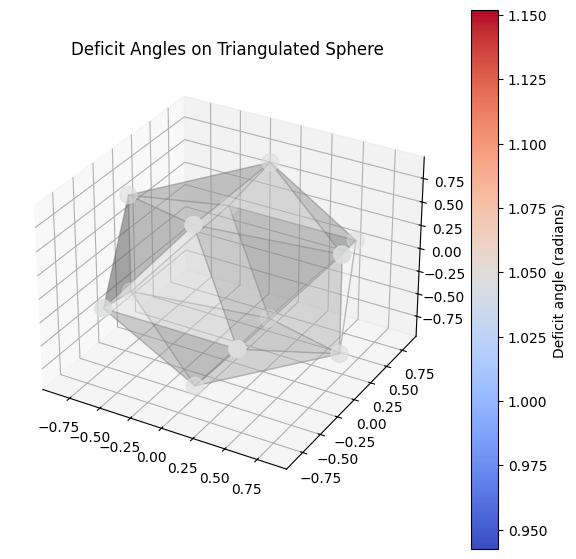

Max deficit (interior): 1.0471975511965974
Sum of all deficits (should be ~4pi for sphere): 12.566370614359158


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

# Create an icosahedron (12 vertices, 20 faces)
def icosahedron():
    phi = (1 + np.sqrt(5)) / 2
    points = []
    for i in [-1, 1]:
        for j in [-1, 1]:
            points.append([0, i, j * phi])
            points.append([i, j * phi, 0])
            points.append([i * phi, 0, j])
    points = np.array(points)
    points /= np.linalg.norm(points[0])
    return points

points = icosahedron()
hull = ConvexHull(points)
triangles = hull.simplices

def deficit_angle_sphere(points, triangles):
    N = len(points)
    deficit = np.zeros(N)
    # Build list of triangles for each vertex
    vertex_tris = [[] for _ in range(N)]
    for tri_idx, tri in enumerate(triangles):
        for v in tri:
            vertex_tris[v].append(tri_idx)
    # For each vertex, sum incident angles
    for i, tris in enumerate(vertex_tris):
        angles = []
        p0 = points[i]
        for tri_idx in tris:
            tri = triangles[tri_idx]
            idx = list(tri)
            idx.remove(i)
            p1, p2 = points[idx[0]], points[idx[1]]
            v1, v2 = p1 - p0, p2 - p0
            v1 /= np.linalg.norm(v1)
            v2 /= np.linalg.norm(v2)
            a = np.arccos(np.clip(np.dot(v1, v2), -1, 1))
            angles.append(a)
        deficit[i] = 2*np.pi - np.sum(angles)
    return deficit

deficits = deficit_angle_sphere(points, triangles)

# Plot vertices colored by deficit angle
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(points[:,0], points[:,1], points[:,2], triangles=triangles, color='white', alpha=0.3, edgecolor='gray')
p = ax.scatter(points[:,0], points[:,1], points[:,2], c=deficits, cmap='coolwarm', s=150)
fig.colorbar(p, ax=ax, label="Deficit angle (radians)")
ax.set_title('Deficit Angles on Triangulated Sphere')
plt.show()

print("Max deficit (interior):", np.max(np.abs(deficits)))
print("Sum of all deficits (should be ~4pi for sphere):", np.sum(deficits))

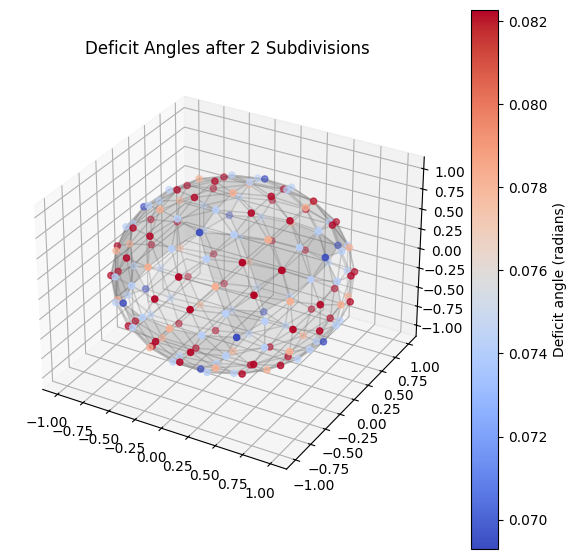

Vertices: 162  Triangles: 320
Max deficit (should shrink as mesh refines): 0.08227110788505065
Sum of all deficits (should be ~4pi for sphere): 12.566370614359142


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

def icosahedron():
    phi = (1 + np.sqrt(5)) / 2
    points = []
    for i in [-1, 1]:
        for j in [-1, 1]:
            points.append([0, i, j * phi])
            points.append([i, j * phi, 0])
            points.append([i * phi, 0, j])
    points = np.array(points)
    points /= np.linalg.norm(points[0])
    return points

def subdivide(points, triangles):
    new_points = points.tolist()
    midpoint_cache = {}
    def midpoint(i, j):
        key = tuple(sorted((i, j)))
        if key in midpoint_cache:
            return midpoint_cache[key]
        else:
            p = (points[i] + points[j]) / 2
            p /= np.linalg.norm(p)
            new_points.append(p)
            idx = len(new_points) - 1
            midpoint_cache[key] = idx
            return idx
    new_triangles = []
    for tri in triangles:
        i, j, k = tri
        a = midpoint(i, j)
        b = midpoint(j, k)
        c = midpoint(k, i)
        new_triangles += [
            [i, a, c],
            [a, j, b],
            [c, b, k],
            [a, b, c],
        ]
    return np.array(new_points), np.array(new_triangles)

def deficit_angle_sphere(points, triangles):
    N = len(points)
    deficit = np.zeros(N)
    vertex_tris = [[] for _ in range(N)]
    for tri_idx, tri in enumerate(triangles):
        for v in tri:
            vertex_tris[v].append(tri_idx)
    for i, tris in enumerate(vertex_tris):
        angles = []
        p0 = points[i]
        for tri_idx in tris:
            tri = triangles[tri_idx]
            idx = list(tri)
            idx.remove(i)
            p1, p2 = points[idx[0]], points[idx[1]]
            v1, v2 = p1 - p0, p2 - p0
            v1 /= np.linalg.norm(v1)
            v2 /= np.linalg.norm(v2)
            a = np.arccos(np.clip(np.dot(v1, v2), -1, 1))
            angles.append(a)
        deficit[i] = 2 * np.pi - np.sum(angles)
    return deficit

# Subdivide the icosahedron multiple times
points = icosahedron()
hull = ConvexHull(points)
triangles = hull.simplices
subdivisions = 2  # Increase to 3 or 4 for finer mesh (will take longer)
for _ in range(subdivisions):
    points, triangles = subdivide(points, triangles)

deficits = deficit_angle_sphere(points, triangles)

# Plot vertices colored by deficit angle
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(points[:,0], points[:,1], points[:,2], triangles=triangles, color='white', alpha=0.2, edgecolor='gray')
p = ax.scatter(points[:,0], points[:,1], points[:,2], c=deficits, cmap='coolwarm', s=20)
fig.colorbar(p, ax=ax, label="Deficit angle (radians)")
ax.set_title(f'Deficit Angles after {subdivisions} Subdivisions')
plt.show()

print(f"Vertices: {len(points)}  Triangles: {len(triangles)}")
print("Max deficit (should shrink as mesh refines):", np.max(np.abs(deficits)))
print("Sum of all deficits (should be ~4pi for sphere):", np.sum(deficits))

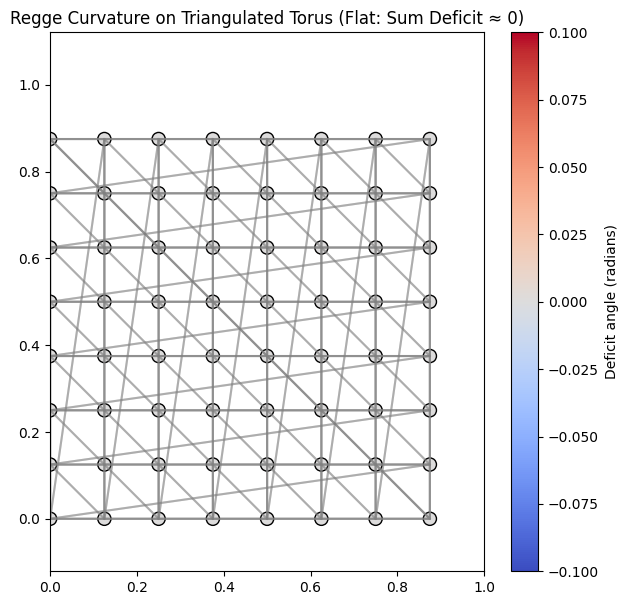

Vertices: 64, Triangles: 128
Max deficit angle (radians): 0.0
Sum of all deficit angles (should be ~0 for torus): 0.0


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Torus triangulation parameters ---
Nx, Ny = 8, 8  # grid size (try 16,16 for finer mesh)

# --- 1. Generate periodic grid points on a torus ---
x = np.arange(Nx) / Nx
y = np.arange(Ny) / Ny
xx, yy = np.meshgrid(x, y)
points = np.vstack([xx.ravel(), yy.ravel()]).T

# --- 2. Build triangles with periodic boundary conditions ---
def grid_triangles(Nx, Ny):
    triangles = []
    def idx(i, j):
        return ((i % Nx) + Nx * (j % Ny))
    for i in range(Nx):
        for j in range(Ny):
            triangles.append([idx(i, j), idx(i+1, j), idx(i, j+1)])
            triangles.append([idx(i+1, j), idx(i+1, j+1), idx(i, j+1)])
    return np.array(triangles)

triangles = grid_triangles(Nx, Ny)

# --- 3. Assign fixed entanglement to each edge for flat torus ---
edges = set()
for t in triangles:
    for k in range(3):
        a, b = sorted((t[k], t[(k+1)%3]))
        edges.add((a, b))
edges = list(edges)

entanglement = {e: np.exp(-1) for e in edges}  # All edge lengths = 1

def edge_length(E):
    return -np.log(E) if E > 0 else 1e6

edge_lengths = {e: edge_length(entanglement[e]) for e in edges}

# --- 4. Compute angles in each triangle ---
def triangle_angles(lens):
    a, b, c = lens
    # Law of cosines with safe clipping
    argA = np.clip((b**2 + c**2 - a**2) / (2*b*c), -1.0, 1.0)
    argB = np.clip((a**2 + c**2 - b**2) / (2*a*c), -1.0, 1.0)
    angle_A = np.arccos(argA)
    angle_B = np.arccos(argB)
    angle_C = np.pi - angle_A - angle_B
    return angle_A, angle_B, angle_C

vertex_angle_sum = np.zeros(Nx * Ny)
for t in triangles:
    idx = [t[0], t[1], t[2]]
    l = []
    for k in range(3):
        a, b = sorted((idx[k], idx[(k+1)%3]))
        l.append(edge_lengths[(a, b)])
    angles = triangle_angles(l)
    if not np.any(np.isnan(angles)):
        for k in range(3):
            vertex_angle_sum[idx[k]] += angles[k]

# --- 5. Deficit angles ---
deficit_angles = 2 * np.pi - vertex_angle_sum

# --- 6. Plot (use torus coordinates for clarity) ---
plt.figure(figsize=(7, 7))
for t in triangles:
    pts = points[t]
    # Wrap for torus periodicity
    dx = np.diff(np.vstack([pts, pts[0]]), axis=0)
    dx[dx > 0.5] -= 1
    dx[dx < -0.5] += 1
    pts_wrapped = pts[0] + np.cumsum(np.vstack([[0, 0], dx]), axis=0)
    plt.plot(pts_wrapped[:, 0] % 1, pts_wrapped[:, 1] % 1, color='gray', alpha=0.4)
sc = plt.scatter(points[:, 0], points[:, 1], c=deficit_angles, cmap='coolwarm', s=90, edgecolors='k')
plt.colorbar(sc, label="Deficit angle (radians)")
plt.title('Regge Curvature on Triangulated Torus (Flat: Sum Deficit ≈ 0)')
plt.axis('equal')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

print(f"Vertices: {Nx*Ny}, Triangles: {len(triangles)}")
print("Max deficit angle (radians):", np.max(np.abs(deficit_angles)))
print("Sum of all deficit angles (should be ~0 for torus):", np.sum(deficit_angles))

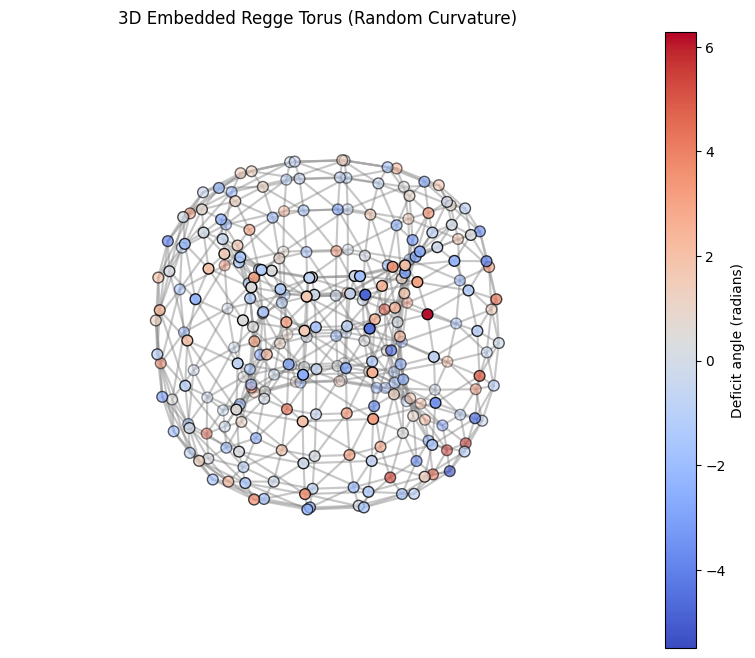

Vertices: 256, Triangles: 512
Max deficit angle (radians): 6.283185307179586
Min deficit angle (radians): -5.493940128951859
Sum of all deficit angles (should be ~0 for torus): -1.3322676295501878e-14


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Torus parameters
Nx, Ny = 16, 16        # mesh resolution
R = 2.0                # major radius (distance from center to tube center)
r = 0.8                # minor radius (tube radius)

# --- 1. Generate grid points on a torus ---
theta = np.linspace(0, 2 * np.pi, Nx, endpoint=False)
phi = np.linspace(0, 2 * np.pi, Ny, endpoint=False)
theta, phi = np.meshgrid(theta, phi)
theta = theta.ravel()
phi = phi.ravel()

# 3D positions
x = (R + r * np.cos(phi)) * np.cos(theta)
y = (R + r * np.cos(phi)) * np.sin(theta)
z = r * np.sin(phi)
points = np.vstack([x, y, z]).T

# --- 2. Build triangles with periodic boundary conditions ---
def grid_triangles(Nx, Ny):
    triangles = []
    def idx(i, j):
        return ((i % Nx) + Nx * (j % Ny))
    for i in range(Nx):
        for j in range(Ny):
            triangles.append([idx(i, j), idx(i+1, j), idx(i, j+1)])
            triangles.append([idx(i+1, j), idx(i+1, j+1), idx(i, j+1)])
    return np.array(triangles)

triangles = grid_triangles(Nx, Ny)

# --- 3. Assign random entanglement to each edge for curvature ---
np.random.seed(0)
edges = set()
for t in triangles:
    for k in range(3):
        a, b = sorted((t[k], t[(k+1)%3]))
        edges.add((a, b))
edges = list(edges)

# Random entanglement in [0.7, 1.0] (tunable)
entanglement = {e: 0.7 + 0.3 * np.random.rand() for e in edges}

def edge_length(E):
    return -np.log(E) if E > 0 else 1e6

edge_lengths = {e: edge_length(entanglement[e]) for e in edges}

# --- 4. Compute angles in each triangle ---
def triangle_angles(lens):
    a, b, c = lens
    argA = np.clip((b**2 + c**2 - a**2) / (2*b*c), -1.0, 1.0)
    argB = np.clip((a**2 + c**2 - b**2) / (2*a*c), -1.0, 1.0)
    angle_A = np.arccos(argA)
    angle_B = np.arccos(argB)
    angle_C = np.pi - angle_A - angle_B
    return angle_A, angle_B, angle_C

vertex_angle_sum = np.zeros(Nx * Ny)
for t in triangles:
    idx = [t[0], t[1], t[2]]
    l = []
    for k in range(3):
        a, b = sorted((idx[k], idx[(k+1)%3]))
        l.append(edge_lengths[(a, b)])
    angles = triangle_angles(l)
    if not np.any(np.isnan(angles)):
        for k in range(3):
            vertex_angle_sum[idx[k]] += angles[k]

# --- 5. Deficit angles ---
deficit_angles = 2 * np.pi - vertex_angle_sum

# --- 6. 3D Plot ---
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for t in triangles:
    pts = points[t]
    ax.plot(pts[[0, 1, 2, 0], 0], pts[[0, 1, 2, 0], 1], pts[[0, 1, 2, 0], 2], color='gray', alpha=0.25)
p = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=deficit_angles, cmap='coolwarm', s=60, edgecolors='k')
fig.colorbar(p, ax=ax, label="Deficit angle (radians)")
ax.set_title('3D Embedded Regge Torus (Random Curvature)')
ax.set_axis_off()
plt.show()

print(f"Vertices: {Nx*Ny}, Triangles: {len(triangles)}")
print("Max deficit angle (radians):", np.max(deficit_angles))
print("Min deficit angle (radians):", np.min(deficit_angles))
print("Sum of all deficit angles (should be ~0 for torus):", np.sum(deficit_angles))

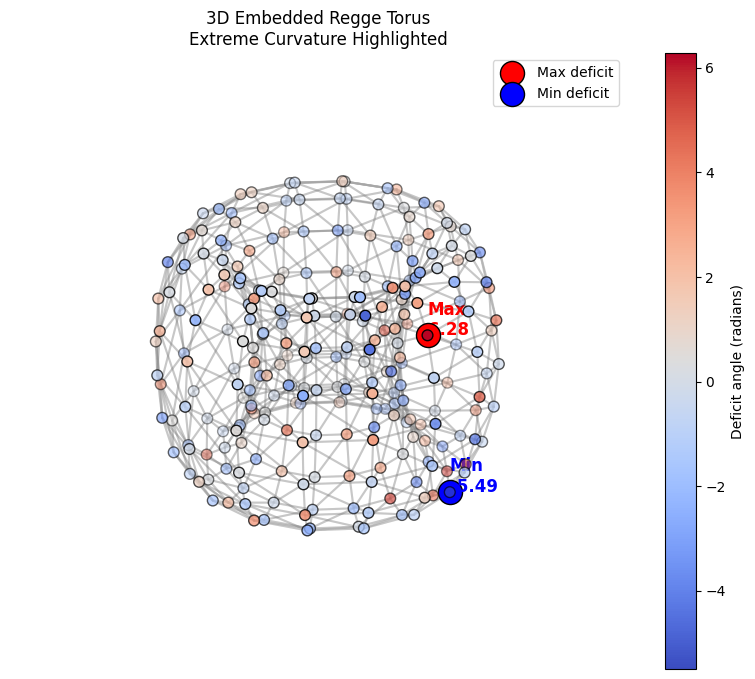

Vertices: 256, Triangles: 512
Max deficit angle at vertex 47 = 6.283185307179586
Min deficit angle at vertex 208 = -5.493940128951859
Sum of all deficit angles (should be ~0 for torus): -1.3322676295501878e-14


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Torus parameters
Nx, Ny = 16, 16        # mesh resolution
R = 2.0                # major radius (distance from center to tube center)
r = 0.8                # minor radius (tube radius)

# --- 1. Generate grid points on a torus ---
theta = np.linspace(0, 2 * np.pi, Nx, endpoint=False)
phi = np.linspace(0, 2 * np.pi, Ny, endpoint=False)
theta, phi = np.meshgrid(theta, phi)
theta = theta.ravel()
phi = phi.ravel()

# 3D positions
x = (R + r * np.cos(phi)) * np.cos(theta)
y = (R + r * np.cos(phi)) * np.sin(theta)
z = r * np.sin(phi)
points = np.vstack([x, y, z]).T

# --- 2. Build triangles with periodic boundary conditions ---
def grid_triangles(Nx, Ny):
    triangles = []
    def idx(i, j):
        return ((i % Nx) + Nx * (j % Ny))
    for i in range(Nx):
        for j in range(Ny):
            triangles.append([idx(i, j), idx(i+1, j), idx(i, j+1)])
            triangles.append([idx(i+1, j), idx(i+1, j+1), idx(i, j+1)])
    return np.array(triangles)

triangles = grid_triangles(Nx, Ny)

# --- 3. Assign random entanglement to each edge for curvature ---
np.random.seed(0)
edges = set()
for t in triangles:
    for k in range(3):
        a, b = sorted((t[k], t[(k+1)%3]))
        edges.add((a, b))
edges = list(edges)

# Random entanglement in [0.7, 1.0]
entanglement = {e: 0.7 + 0.3 * np.random.rand() for e in edges}

def edge_length(E):
    return -np.log(E) if E > 0 else 1e6

edge_lengths = {e: edge_length(entanglement[e]) for e in edges}

# --- 4. Compute angles in each triangle ---
def triangle_angles(lens):
    a, b, c = lens
    argA = np.clip((b**2 + c**2 - a**2) / (2*b*c), -1.0, 1.0)
    argB = np.clip((a**2 + c**2 - b**2) / (2*a*c), -1.0, 1.0)
    angle_A = np.arccos(argA)
    angle_B = np.arccos(argB)
    angle_C = np.pi - angle_A - angle_B
    return angle_A, angle_B, angle_C

vertex_angle_sum = np.zeros(Nx * Ny)
for t in triangles:
    idx = [t[0], t[1], t[2]]
    l = []
    for k in range(3):
        a, b = sorted((idx[k], idx[(k+1)%3]))
        l.append(edge_lengths[(a, b)])
    angles = triangle_angles(l)
    if not np.any(np.isnan(angles)):
        for k in range(3):
            vertex_angle_sum[idx[k]] += angles[k]

# --- 5. Deficit angles ---
deficit_angles = 2 * np.pi - vertex_angle_sum

# --- 6. Find and highlight extreme curvature vertices ---
max_idx = np.argmax(deficit_angles)
min_idx = np.argmin(deficit_angles)

# --- 7. 3D Plot with highlights ---
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw mesh
for t in triangles:
    pts = points[t]
    ax.plot(pts[[0, 1, 2, 0], 0], pts[[0, 1, 2, 0], 1], pts[[0, 1, 2, 0], 2], color='gray', alpha=0.25)

# Main scatter plot
p = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=deficit_angles, cmap='coolwarm', s=60, edgecolors='k')

# Highlight max/min deficit vertices
ax.scatter(points[max_idx, 0], points[max_idx, 1], points[max_idx, 2],
           color='red', s=300, edgecolors='black', label='Max deficit')
ax.scatter(points[min_idx, 0], points[min_idx, 1], points[min_idx, 2],
           color='blue', s=300, edgecolors='black', label='Min deficit')

# Optionally, add labels with deficit values
ax.text(points[max_idx, 0], points[max_idx, 1], points[max_idx, 2],
        f"Max\n{deficit_angles[max_idx]:.2f}", color='red', fontsize=12, weight='bold')
ax.text(points[min_idx, 0], points[min_idx, 1], points[min_idx, 2],
        f"Min\n{deficit_angles[min_idx]:.2f}", color='blue', fontsize=12, weight='bold')

fig.colorbar(p, ax=ax, label="Deficit angle (radians)")
ax.set_title('3D Embedded Regge Torus\nExtreme Curvature Highlighted')
ax.set_axis_off()
ax.legend()
plt.show()

print(f"Vertices: {Nx*Ny}, Triangles: {len(triangles)}")
print("Max deficit angle at vertex", max_idx, "=", deficit_angles[max_idx])
print("Min deficit angle at vertex", min_idx, "=", deficit_angles[min_idx])
print("Sum of all deficit angles (should be ~0 for torus):", np.sum(deficit_angles))

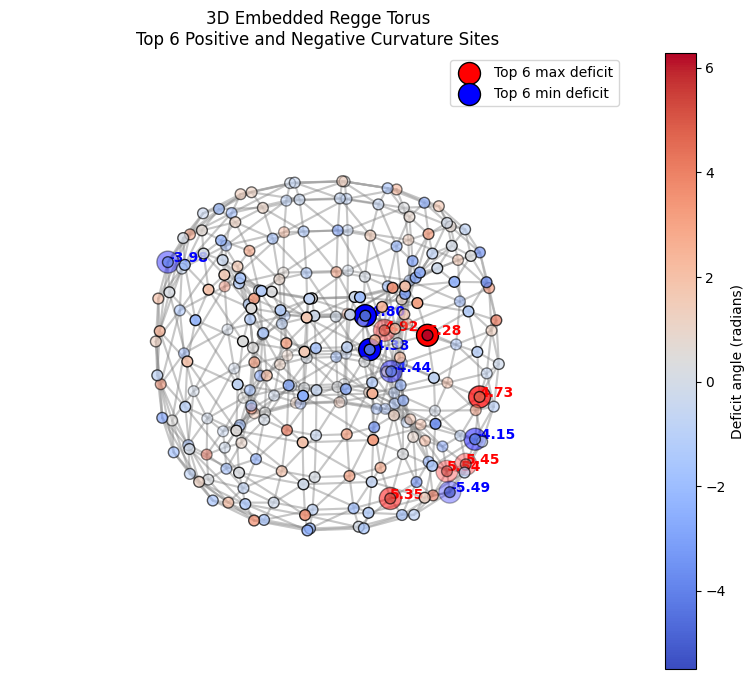

Vertices: 256, Triangles: 512
Top 6 deficit angles: [6.28318531 5.53590615 5.45413322 5.34561809 4.91896939 4.73447351]
Bottom 6 deficit angles: [-5.49394013 -4.79920824 -4.43920613 -4.380816   -4.14779008 -3.97821876]
Sum of all deficit angles (should be ~0 for torus): -1.3322676295501878e-14


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Torus parameters
Nx, Ny = 16, 16        # mesh resolution
R = 2.0                # major radius (distance from center to tube center)
r = 0.8                # minor radius (tube radius)

# --- 1. Generate grid points on a torus ---
theta = np.linspace(0, 2 * np.pi, Nx, endpoint=False)
phi = np.linspace(0, 2 * np.pi, Ny, endpoint=False)
theta, phi = np.meshgrid(theta, phi)
theta = theta.ravel()
phi = phi.ravel()

# 3D positions
x = (R + r * np.cos(phi)) * np.cos(theta)
y = (R + r * np.cos(phi)) * np.sin(theta)
z = r * np.sin(phi)
points = np.vstack([x, y, z]).T

# --- 2. Build triangles with periodic boundary conditions ---
def grid_triangles(Nx, Ny):
    triangles = []
    def idx(i, j):
        return ((i % Nx) + Nx * (j % Ny))
    for i in range(Nx):
        for j in range(Ny):
            triangles.append([idx(i, j), idx(i+1, j), idx(i, j+1)])
            triangles.append([idx(i+1, j), idx(i+1, j+1), idx(i, j+1)])
    return np.array(triangles)

triangles = grid_triangles(Nx, Ny)

# --- 3. Assign random entanglement to each edge for curvature ---
np.random.seed(0)
edges = set()
for t in triangles:
    for k in range(3):
        a, b = sorted((t[k], t[(k+1)%3]))
        edges.add((a, b))
edges = list(edges)

# Random entanglement in [0.7, 1.0]
entanglement = {e: 0.7 + 0.3 * np.random.rand() for e in edges}

def edge_length(E):
    return -np.log(E) if E > 0 else 1e6

edge_lengths = {e: edge_length(entanglement[e]) for e in edges}

# --- 4. Compute angles in each triangle ---
def triangle_angles(lens):
    a, b, c = lens
    argA = np.clip((b**2 + c**2 - a**2) / (2*b*c), -1.0, 1.0)
    argB = np.clip((a**2 + c**2 - b**2) / (2*a*c), -1.0, 1.0)
    angle_A = np.arccos(argA)
    angle_B = np.arccos(argB)
    angle_C = np.pi - angle_A - angle_B
    return angle_A, angle_B, angle_C

vertex_angle_sum = np.zeros(Nx * Ny)
for t in triangles:
    idx = [t[0], t[1], t[2]]
    l = []
    for k in range(3):
        a, b = sorted((idx[k], idx[(k+1)%3]))
        l.append(edge_lengths[(a, b)])
    angles = triangle_angles(l)
    if not np.any(np.isnan(angles)):
        for k in range(3):
            vertex_angle_sum[idx[k]] += angles[k]

# --- 5. Deficit angles ---
deficit_angles = 2 * np.pi - vertex_angle_sum

# --- 6. Find top/bottom 6 deficit vertices ---
N = 6
topN_idx = np.argsort(deficit_angles)[-N:][::-1]   # 6 largest
botN_idx = np.argsort(deficit_angles)[:N]          # 6 smallest

# --- 7. 3D Plot with highlights ---
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw mesh
for t in triangles:
    pts = points[t]
    ax.plot(pts[[0, 1, 2, 0], 0], pts[[0, 1, 2, 0], 1], pts[[0, 1, 2, 0], 2], color='gray', alpha=0.25)

# Main scatter plot
p = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=deficit_angles, cmap='coolwarm', s=60, edgecolors='k')

# Highlight top 6 (red) and bottom 6 (blue)
ax.scatter(points[topN_idx, 0], points[topN_idx, 1], points[topN_idx, 2],
           color='red', s=250, edgecolors='black', label='Top 6 max deficit')
ax.scatter(points[botN_idx, 0], points[botN_idx, 1], points[botN_idx, 2],
           color='blue', s=250, edgecolors='black', label='Top 6 min deficit')

# Add deficit value labels for each highlighted site
for idx in topN_idx:
    ax.text(points[idx, 0], points[idx, 1], points[idx, 2],
            f"{deficit_angles[idx]:.2f}", color='red', fontsize=10, weight='bold')
for idx in botN_idx:
    ax.text(points[idx, 0], points[idx, 1], points[idx, 2],
            f"{deficit_angles[idx]:.2f}", color='blue', fontsize=10, weight='bold')

fig.colorbar(p, ax=ax, label="Deficit angle (radians)")
ax.set_title('3D Embedded Regge Torus\nTop 6 Positive and Negative Curvature Sites')
ax.set_axis_off()
ax.legend()
plt.show()

print(f"Vertices: {Nx*Ny}, Triangles: {len(triangles)}")
print("Top 6 deficit angles:", deficit_angles[topN_idx])
print("Bottom 6 deficit angles:", deficit_angles[botN_idx])
print("Sum of all deficit angles (should be ~0 for torus):", np.sum(deficit_angles))

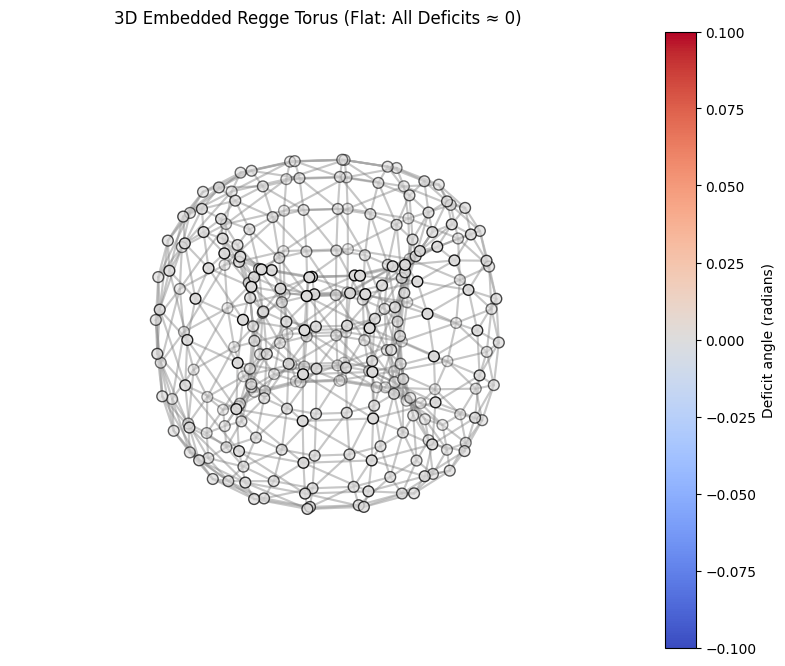

Vertices: 256, Triangles: 512
Max deficit angle (radians): 0.0
Sum of all deficit angles (should be ~0 for torus): 0.0


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Torus parameters
Nx, Ny = 16, 16        # mesh resolution
R = 2.0                # major radius (distance from center to tube center)
r = 0.8                # minor radius (tube radius)

# --- 1. Generate grid points on a torus ---
theta = np.linspace(0, 2 * np.pi, Nx, endpoint=False)
phi = np.linspace(0, 2 * np.pi, Ny, endpoint=False)
theta, phi = np.meshgrid(theta, phi)
theta = theta.ravel()
phi = phi.ravel()

# 3D positions
x = (R + r * np.cos(phi)) * np.cos(theta)
y = (R + r * np.cos(phi)) * np.sin(theta)
z = r * np.sin(phi)
points = np.vstack([x, y, z]).T

# --- 2. Build triangles with periodic boundary conditions ---
def grid_triangles(Nx, Ny):
    triangles = []
    def idx(i, j):
        return ((i % Nx) + Nx * (j % Ny))
    for i in range(Nx):
        for j in range(Ny):
            triangles.append([idx(i, j), idx(i+1, j), idx(i, j+1)])
            triangles.append([idx(i+1, j), idx(i+1, j+1), idx(i, j+1)])
    return np.array(triangles)

triangles = grid_triangles(Nx, Ny)

# --- 3. Assign fixed entanglement to each edge for flat torus ---
edges = set()
for t in triangles:
    for k in range(3):
        a, b = sorted((t[k], t[(k+1)%3]))
        edges.add((a, b))
edges = list(edges)

entanglement = {e: np.exp(-1) for e in edges}  # All edge lengths = 1

def edge_length(E):
    return -np.log(E) if E > 0 else 1e6

edge_lengths = {e: edge_length(entanglement[e]) for e in edges}

# --- 4. Compute angles in each triangle ---
def triangle_angles(lens):
    a, b, c = lens
    argA = np.clip((b**2 + c**2 - a**2) / (2*b*c), -1.0, 1.0)
    argB = np.clip((a**2 + c**2 - b**2) / (2*a*c), -1.0, 1.0)
    angle_A = np.arccos(argA)
    angle_B = np.arccos(argB)
    angle_C = np.pi - angle_A - angle_B
    return angle_A, angle_B, angle_C

vertex_angle_sum = np.zeros(Nx * Ny)
for t in triangles:
    idx = [t[0], t[1], t[2]]
    l = []
    for k in range(3):
        a, b = sorted((idx[k], idx[(k+1)%3]))
        l.append(edge_lengths[(a, b)])
    angles = triangle_angles(l)
    if not np.any(np.isnan(angles)):
        for k in range(3):
            vertex_angle_sum[idx[k]] += angles[k]

# --- 5. Deficit angles ---
deficit_angles = 2 * np.pi - vertex_angle_sum

# --- 6. 3D Plot ---
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
# Draw mesh
for t in triangles:
    pts = points[t]
    ax.plot(pts[[0, 1, 2, 0], 0], pts[[0, 1, 2, 0], 1], pts[[0, 1, 2, 0], 2], color='gray', alpha=0.25)
# Scatter vertices colored by deficit
p = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=deficit_angles, cmap='coolwarm', s=60, edgecolors='k')
fig.colorbar(p, ax=ax, label="Deficit angle (radians)")
ax.set_title('3D Embedded Regge Torus (Flat: All Deficits ≈ 0)')
ax.set_axis_off()
plt.show()

print(f"Vertices: {Nx*Ny}, Triangles: {len(triangles)}")
print("Max deficit angle (radians):", np.max(np.abs(deficit_angles)))
print("Sum of all deficit angles (should be ~0 for torus):", np.sum(deficit_angles))